In [1]:
import os, sys
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef

ROOT = r"C:\Users\ACER\Desktop\NeuroNest"
if ROOT not in sys.path:
    sys.path.append(ROOT)

from ml.fracture_cls.training.dataset import FractureDataset
from ml.fracture_cls.models.densenet121 import build_densenet121_binary

print("all imports done")

all imports done


In [2]:
# paths and settings 
CKPT_PATH  = os.path.join(ROOT, "ml", "fracture_cls", "checkpoints", "best_densenet121_fracture.pth")
DATA_ROOT  = os.path.join(ROOT, "Data", "fracture_clean")
VAL_DIR    = os.path.join(DATA_ROOT, "val")
TEST_DIR   = os.path.join(DATA_ROOT, "test")

# IMAGE_SIZE must match what the model was trained on
# THRESHOLD is the cutoff — above 0.5 = fracture, below = normal
BATCH_SIZE = 16
IMAGE_SIZE = 224
THRESHOLD  = 0.5
CLASSES    = ["NORMAL", "FRACTURE"]
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("using device:", DEVICE)
print("checkpoint:", CKPT_PATH)

using device: cuda
checkpoint: C:\Users\ACER\Desktop\NeuroNest\ml\fracture_cls\checkpoints\best_densenet121_fracture.pth


In [3]:
# loading the val and test datasets and wrapping them in dataloaders
# train=False means no data augmentation — we want clean unmodified images for evaluation
val_ds      = FractureDataset(VAL_DIR,  image_size=IMAGE_SIZE, train=False, log_bad=False)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_ds     = FractureDataset(TEST_DIR, image_size=IMAGE_SIZE, train=False, log_bad=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"val  — {len(val_ds)} images  | normal: {sum(1 for _,l in val_ds.samples if l==0)}  fracture: {sum(1 for _,l in val_ds.samples if l==1)}")
print(f"test — {len(test_ds)} images | normal: {sum(1 for _,l in test_ds.samples if l==0)}  fracture: {sum(1 for _,l in test_ds.samples if l==1)}")

val  — 581 images  | normal: 341  fracture: 240
test — 581 images | normal: 341  fracture: 240


In [6]:
# building the densenet model and loading the saved weights
# weights_only=False because the checkpoint also stores extra info like arch name and best F1
model = build_densenet121_binary(pretrained=False).to(DEVICE)
ckpt  = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("model loaded, architecture:", ckpt.get("arch", "densenet121"))

model loaded, architecture: densenet121


In [ ]:
# running the model on all images in a given loader and collecting predicted probabilities
# sigmoid converts the raw model output to a probability between 0 and 1
def run_inference(loader):
    all_probs, all_labels = [], []
    with torch.inference_mode():
        for x, y in tqdm(loader, desc="running inference"):
            x      = x.to(DEVICE)
            probs  = torch.sigmoid(model(x)).cpu().numpy().flatten()
            labels = y.numpy().flatten().astype(int)
            all_probs.extend(probs)
            all_labels.extend(labels)
    return np.array(all_probs), np.array(all_labels)

# run on both val and test sets
val_probs,  val_labels  = run_inference(val_loader)
test_probs, test_labels = run_inference(test_loader)

# apply the threshold to get final binary predictions (0 = normal, 1 = fracture)
val_preds  = (val_probs  >= THRESHOLD).astype(int)
test_preds = (test_probs >= THRESHOLD).astype(int)



running inference:   0%|          | 0/37 [00:00<?, ?it/s]

running inference:   0%|          | 0/37 [00:00<?, ?it/s]

c:\Users\ACER\Desktop\NeuroNest\.venv\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


done!


In [7]:
# computing all the evaluation metrics from the predictions
# MCC (Matthews Correlation Coefficient) is a good overall metric when classes are imbalanced
def compute_metrics(labels, preds, split_name):
    tp  = int(((preds==1)&(labels==1)).sum())
    tn  = int(((preds==0)&(labels==0)).sum())
    fp  = int(((preds==1)&(labels==0)).sum())
    fn  = int(((preds==0)&(labels==1)).sum())
    eps = 1e-9

    acc  = (tp+tn) / (tp+tn+fp+fn+eps)
    prec = tp / (tp+fp+eps)
    rec  = tp / (tp+fn+eps)       # also called sensitivity
    spec = tn / (tn+fp+eps)       # true negative rate
    f1   = 2*prec*rec / (prec+rec+eps)
    mcc  = matthews_corrcoef(labels, preds)

    m = dict(Accuracy=acc, Precision=prec, Recall=rec, Specificity=spec, F1=f1, MCC=mcc,
             TP=tp, TN=tn, FP=fp, FN=fn)

    print(f"\n{split_name} results:")
    for k, v in m.items():
        if k not in ("TP", "TN", "FP", "FN"):
            print(f"  {k:<14}: {v:.4f}")
    print(f"  counts        : TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    return m

val_m  = compute_metrics(val_labels,  val_preds,  "validation")
test_m = compute_metrics(test_labels, test_preds, "test")


validation results:
  Accuracy      : 0.8227
  Precision     : 0.7217
  Recall        : 0.9292
  Specificity   : 0.7478
  F1            : 0.8124
  MCC           : 0.6680
  counts        : TP=223  TN=255  FP=86  FN=17

test results:
  Accuracy      : 0.7969
  Precision     : 0.7047
  Recall        : 0.8750
  Specificity   : 0.7419
  F1            : 0.7807
  MCC           : 0.6077
  counts        : TP=210  TN=253  FP=88  FN=30


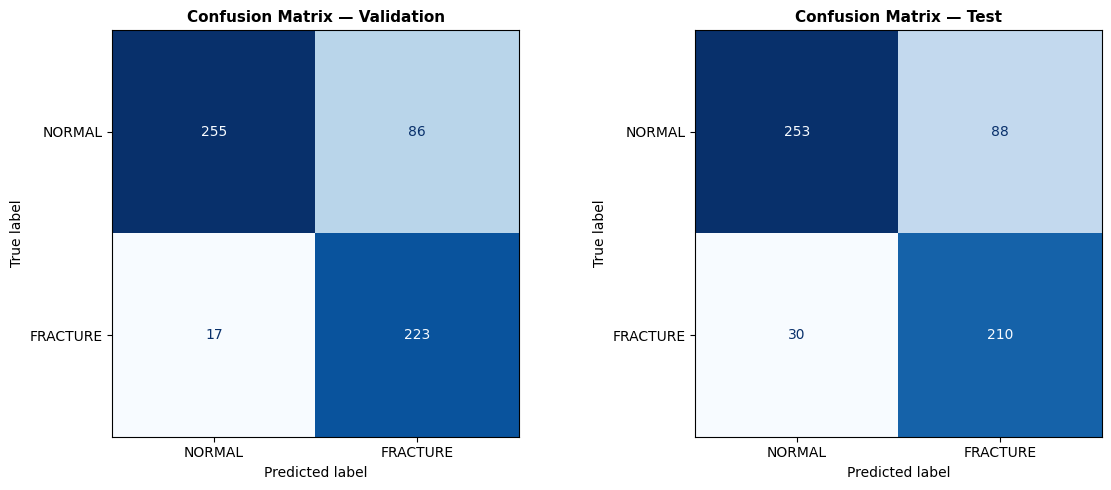

In [8]:
# plotting confusion matrices for both val and test side by side
# rows = actual labels, columns = predicted labels
# ideally we want high numbers on the diagonal (top-left and bottom-right)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, labels, preds) in zip(axes, [("Validation", val_labels, val_preds),
                                              ("Test",       test_labels, test_preds)]):
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()